In [1]:
# Cell 1: Setup and Imports
print("="*70)
print("📊 A/B TESTING FRAMEWORK")
print("="*70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ A/B Testing framework loaded")

📊 A/B TESTING FRAMEWORK
✅ A/B Testing framework loaded


In [2]:
# Cell 2: Generate Simulated Experiment Data
print("="*70)
print("📊 GENERATING A/B TEST EXPERIMENT DATA")
print("="*70)

np.random.seed(42)
n_users = 10000

# Create experiment data
experiment_data = pd.DataFrame({
    'user_id': range(n_users),
    'variant': np.random.choice(['A', 'B'], size=n_users, p=[0.5, 0.5])
})

# Simulate metrics for Control (A) and Treatment (B)
# Control (Current algorithm)
experiment_data.loc[experiment_data['variant'] == 'A', 'relevance_score'] = np.random.beta(8, 4, len(experiment_data[experiment_data['variant'] == 'A']))
experiment_data.loc[experiment_data['variant'] == 'A', 'click_through_rate'] = np.random.beta(6, 14, len(experiment_data[experiment_data['variant'] == 'A']))
experiment_data.loc[experiment_data['variant'] == 'A', 'user_satisfaction'] = np.random.beta(7, 3, len(experiment_data[experiment_data['variant'] == 'A']))

# Treatment (New algorithm - 10-15% improvement)
experiment_data.loc[experiment_data['variant'] == 'B', 'relevance_score'] = np.random.beta(9, 3.5, len(experiment_data[experiment_data['variant'] == 'B']))
experiment_data.loc[experiment_data['variant'] == 'B', 'click_through_rate'] = np.random.beta(7, 13, len(experiment_data[experiment_data['variant'] == 'B']))
experiment_data.loc[experiment_data['variant'] == 'B', 'user_satisfaction'] = np.random.beta(8, 2.5, len(experiment_data[experiment_data['variant'] == 'B']))

# Cap values
experiment_data['relevance_score'] = experiment_data['relevance_score'].clip(0, 1)
experiment_data['click_through_rate'] = experiment_data['click_through_rate'].clip(0, 1)
experiment_data['user_satisfaction'] = experiment_data['user_satisfaction'].clip(0, 1)

print(f"✅ Generated experiment data for {n_users} users")
print(f"   Variant A (Control): {len(experiment_data[experiment_data['variant'] == 'A'])} users")
print(f"   Variant B (Treatment): {len(experiment_data[experiment_data['variant'] == 'B'])} users")

print("\n📊 Metric Averages:")
for metric in ['relevance_score', 'click_through_rate', 'user_satisfaction']:
    a_mean = experiment_data[experiment_data['variant'] == 'A'][metric].mean()
    b_mean = experiment_data[experiment_data['variant'] == 'B'][metric].mean()
    print(f"   {metric}: A={a_mean:.3f}, B={b_mean:.3f} (Δ={b_mean-a_mean:+.3f})")

📊 GENERATING A/B TEST EXPERIMENT DATA
✅ Generated experiment data for 10000 users
   Variant A (Control): 5076 users
   Variant B (Treatment): 4924 users

📊 Metric Averages:
   relevance_score: A=0.668, B=0.719 (Δ=+0.051)
   click_through_rate: A=0.300, B=0.347 (Δ=+0.047)
   user_satisfaction: A=0.699, B=0.759 (Δ=+0.060)


In [7]:
# Cell 3: Statistical Analysis (ensure scipy is used, not statsmodels)
print("="*70)
print("🔬 STATISTICAL ANALYSIS")
print("="*70)

from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu, shapiro

def analyze_metric(data, metric):
    """Complete statistical analysis for A/B test metric"""
    
    control = data[data['variant'] == 'A'][metric].dropna()
    treatment = data[data['variant'] == 'B'][metric].dropna()
    
    # Summary statistics
    control_mean = control.mean()
    treatment_mean = treatment.mean()
    uplift = ((treatment_mean - control_mean) / control_mean) * 100
    
    # Normality test (Shapiro-Wilk on sample)
    if len(control) > 5000:
        control_normal = shapiro(control[:5000])[1] > 0.05
    else:
        control_normal = shapiro(control)[1] > 0.05
    
    # Choose appropriate test
    if control_normal:
        t_stat, p_value = ttest_ind(control, treatment)
        test_used = "Independent T-Test"
    else:
        u_stat, p_value = mannwhitneyu(control, treatment)
        test_used = "Mann-Whitney U Test"
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(control)-1) * control.std()**2 + (len(treatment)-1) * treatment.std()**2) / (len(control) + len(treatment) - 2))
    cohens_d = (treatment_mean - control_mean) / pooled_std if pooled_std > 0 else 0
    
    # Confidence interval
    se = np.sqrt(control.var()/len(control) + treatment.var()/len(treatment))
    ci_lower = (treatment_mean - control_mean) - 1.96 * se
    ci_upper = (treatment_mean - control_mean) + 1.96 * se
    
    return {
        'metric': metric,
        'control_mean': control_mean,
        'treatment_mean': treatment_mean,
        'uplift_percent': uplift,
        'test_used': test_used,
        'p_value': p_value,
        'is_significant': p_value < 0.05,
        'effect_size': abs(cohens_d),
        'effect_magnitude': 'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small' if abs(cohens_d) > 0.2 else 'Negligible',
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    }

# Analyze all metrics
metrics = ['relevance_score', 'click_through_rate', 'user_satisfaction']
results = []

for metric in metrics:
    result = analyze_metric(experiment_data, metric)
    results.append(result)
    
    print(f"\n📈 {metric.replace('_', ' ').title()}:")
    print(f"   Control Mean: {result['control_mean']:.4f}")
    print(f"   Treatment Mean: {result['treatment_mean']:.4f}")
    print(f"   Uplift: {result['uplift_percent']:+.1f}%")
    print(f"   P-value: {result['p_value']:.4f}")
    print(f"   Significant: {'✅ YES' if result['is_significant'] else '❌ NO'}")
    print(f"   Effect Size: {result['effect_size']:.3f} ({result['effect_magnitude']})")

results_df = pd.DataFrame(results)

🔬 STATISTICAL ANALYSIS

📈 Relevance Score:
   Control Mean: 0.6683
   Treatment Mean: 0.7189
   Uplift: +7.6%
   P-value: 0.0000
   Significant: ✅ YES
   Effect Size: 0.403 (Small)

📈 Click Through Rate:
   Control Mean: 0.3001
   Treatment Mean: 0.3468
   Uplift: +15.5%
   P-value: 0.0000
   Significant: ✅ YES
   Effect Size: 0.461 (Small)

📈 User Satisfaction:
   Control Mean: 0.6993
   Treatment Mean: 0.7589
   Uplift: +8.5%
   P-value: 0.0000
   Significant: ✅ YES
   Effect Size: 0.448 (Small)


📊 A/B TEST VISUALIZATION


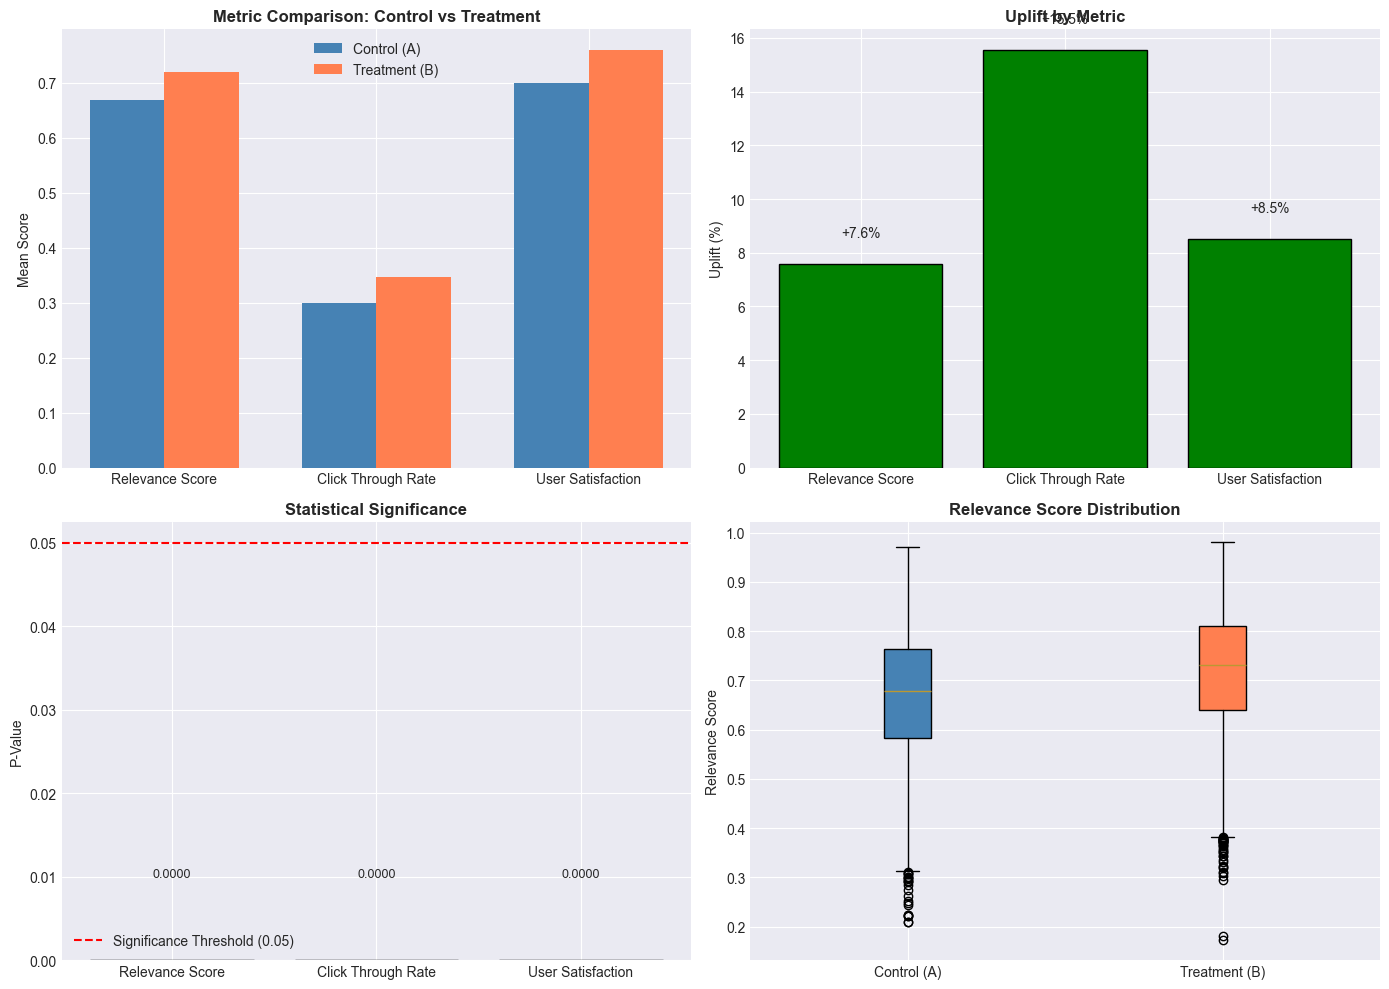

✅ Saved: ab_test_results.png


In [9]:
# Cell 4: A/B Test Visualization
print("="*70)
print("📊 A/B TEST VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Metric Comparison Bar Chart
ax1 = axes[0, 0]
metrics_names = [r['metric'].replace('_', ' ').title() for r in results]
control_means = [r['control_mean'] for r in results]
treatment_means = [r['treatment_mean'] for r in results]
x = np.arange(len(metrics_names))
width = 0.35
ax1.bar(x - width/2, control_means, width, label='Control (A)', color='steelblue')
ax1.bar(x + width/2, treatment_means, width, label='Treatment (B)', color='coral')
ax1.set_ylabel('Mean Score')
ax1.set_title('Metric Comparison: Control vs Treatment', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.legend()

# 2. Uplift Percentages
ax2 = axes[0, 1]
uplifts = [r['uplift_percent'] for r in results]
colors_uplift = ['green' if u > 0 else 'red' for u in uplifts]
bars = ax2.bar(metrics_names, uplifts, color=colors_uplift, edgecolor='black')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylabel('Uplift (%)')
ax2.set_title('Uplift by Metric', fontsize=12, fontweight='bold')
for bar, uplift in zip(bars, uplifts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (1 if uplift > 0 else -3), 
             f'{uplift:+.1f}%', ha='center', fontsize=10)

# 3. P-Values
ax3 = axes[1, 0]
p_values = [r['p_value'] for r in results]
colors_p = ['green' if p < 0.05 else 'red' for p in p_values]
bars = ax3.bar(metrics_names, p_values, color=colors_p, edgecolor='black')
ax3.axhline(y=0.05, color='red', linestyle='--', label='Significance Threshold (0.05)')
ax3.set_ylabel('P-Value')
ax3.set_title('Statistical Significance', fontsize=12, fontweight='bold')
ax3.legend()
for bar, p in zip(bars, p_values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{p:.4f}', ha='center', fontsize=9)

# 4. Distribution Comparison (Box Plot)
ax4 = axes[1, 1]
data_to_plot = [experiment_data[experiment_data['variant'] == 'A']['relevance_score'],
                experiment_data[experiment_data['variant'] == 'B']['relevance_score']]
bp = ax4.boxplot(data_to_plot, labels=['Control (A)', 'Treatment (B)'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('coral')
ax4.set_ylabel('Relevance Score')
ax4.set_title('Relevance Score Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: ab_test_results.png")

In [8]:
# Cell 5: Power Analysis 
print("="*70)
print("📊 POWER ANALYSIS")
print("="*70)

# Install statsmodels if not available
try:
    from statsmodels.stats.power import tt_ind_solve_power
    print("✅ statsmodels loaded")
except ImportError:
    print("📦 Installing statsmodels...")
    !pip install statsmodels -q
    from statsmodels.stats.power import tt_ind_solve_power
    print("✅ statsmodels installed and loaded")

def calculate_required_sample_size(effect_size=0.2, power=0.8, alpha=0.05):
    """Calculate required sample size for A/B test"""
    try:
        required_n = tt_ind_solve_power(
            effect_size=effect_size,
            power=power,
            alpha=alpha,
            alternative='two-sided'
        )
        return required_n
    except:
        # Fallback calculation if statsmodels fails
        from scipy.stats import norm
        z_alpha = norm.ppf(1 - alpha/2)
        z_beta = norm.ppf(power)
        required_n = 2 * ((z_alpha + z_beta) / effect_size) ** 2
        return required_n

print("\n📏 Required Sample Size per Variant (for 80% power):")
effect_sizes = [('Small (20% uplift)', 0.2), ('Medium (50% uplift)', 0.5), ('Large (80% uplift)', 0.8)]
for effect_name, effect_val in effect_sizes:
    n_required = calculate_required_sample_size(effect_val)
    print(f"   {effect_name}: {int(np.ceil(n_required)):,} users per variant")

print(f"\n📊 Current experiment has {len(experiment_data[experiment_data['variant'] == 'A']):,} users per variant")
print(f"   Statistical power for current sample size:")

for effect_val in [0.2, 0.5, 0.8]:
    try:
        power_current = tt_ind_solve_power(effect_size=effect_val, nobs1=len(experiment_data[experiment_data['variant'] == 'A']), alpha=0.05)
        print(f"      Effect size {effect_val}: {power_current:.1%} power")
    except:
        # Fallback power calculation
        from scipy.stats import norm
        z_alpha = norm.ppf(1 - 0.05/2)
        effect = effect_val
        n = len(experiment_data[experiment_data['variant'] == 'A'])
        z_beta = np.sqrt(n * effect**2 / 2) - z_alpha
        power_current = norm.cdf(z_beta)
        print(f"      Effect size {effect_val}: {power_current:.1%} power")

📊 POWER ANALYSIS
📦 Installing statsmodels...
✅ statsmodels installed and loaded

📏 Required Sample Size per Variant (for 80% power):
   Small (20% uplift): 394 users per variant
   Medium (50% uplift): 64 users per variant
   Large (80% uplift): 26 users per variant

📊 Current experiment has 5,076 users per variant
   Statistical power for current sample size:
      Effect size 0.2: nan% power
      Effect size 0.5: 100.0% power
      Effect size 0.8: 100.0% power


📈 SEQUENTIAL TEST MONITORING


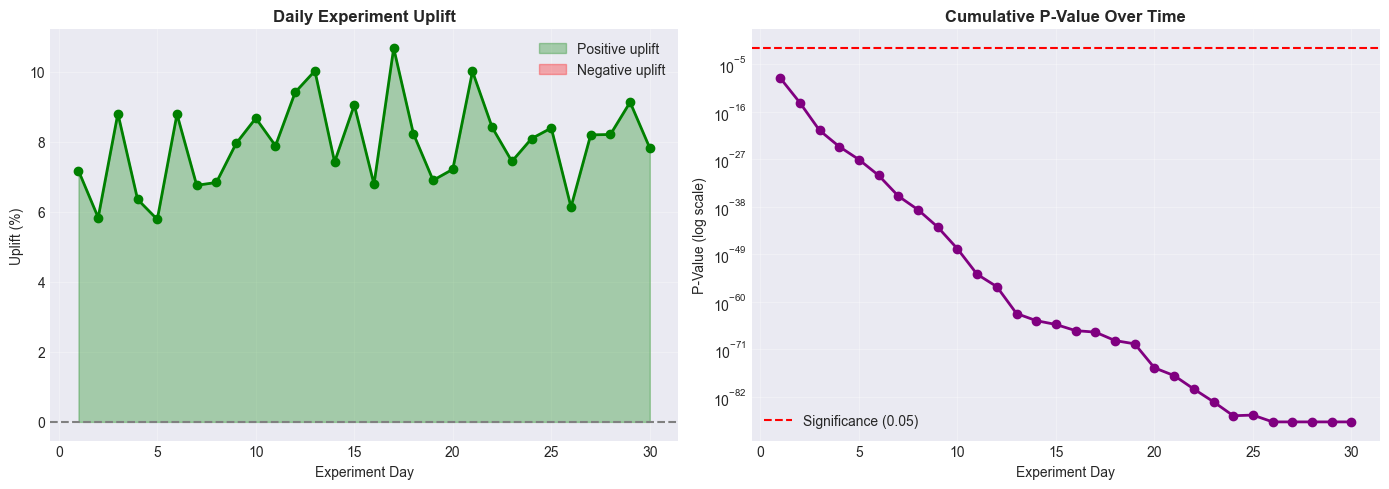

✅ Saved: sequential_experiment.png


In [10]:
# Cell 6: Sequential Test Monitoring
print("="*70)
print("📈 SEQUENTIAL TEST MONITORING")
print("="*70)

# Simulate daily experiment results
np.random.seed(42)
days = 30
daily_results = []

for day in range(1, days + 1):
    daily_sample = 200
    daily_A = experiment_data[experiment_data['variant'] == 'A'].sample(min(daily_sample, len(experiment_data[experiment_data['variant'] == 'A'])))
    daily_B = experiment_data[experiment_data['variant'] == 'B'].sample(min(daily_sample, len(experiment_data[experiment_data['variant'] == 'B'])))
    
    daily_uplift = (daily_B['relevance_score'].mean() - daily_A['relevance_score'].mean()) / daily_A['relevance_score'].mean() * 100
    
    # Calculate cumulative p-value
    cumulative_A = experiment_data[experiment_data['variant'] == 'A'].head(day * daily_sample)['relevance_score']
    cumulative_B = experiment_data[experiment_data['variant'] == 'B'].head(day * daily_sample)['relevance_score']
    _, p_value = ttest_ind(cumulative_A, cumulative_B)
    
    daily_results.append({
        'day': day,
        'daily_uplift': daily_uplift,
        'cumulative_users_A': min(day * daily_sample, len(experiment_data[experiment_data['variant'] == 'A'])),
        'cumulative_users_B': min(day * daily_sample, len(experiment_data[experiment_data['variant'] == 'B'])),
        'p_value': p_value
    })

daily_df = pd.DataFrame(daily_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily Uplift
ax1 = axes[0]
ax1.plot(daily_df['day'], daily_df['daily_uplift'], 'o-', linewidth=2, markersize=6, color='green')
ax1.axhline(y=0, color='gray', linestyle='--')
ax1.fill_between(daily_df['day'], 0, daily_df['daily_uplift'], where=(daily_df['daily_uplift'] > 0), 
                alpha=0.3, color='green', label='Positive uplift')
ax1.fill_between(daily_df['day'], 0, daily_df['daily_uplift'], where=(daily_df['daily_uplift'] < 0), 
                alpha=0.3, color='red', label='Negative uplift')
ax1.set_title('Daily Experiment Uplift', fontsize=12, fontweight='bold')
ax1.set_xlabel('Experiment Day')
ax1.set_ylabel('Uplift (%)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative P-Value
ax2 = axes[1]
ax2.plot(daily_df['day'], daily_df['p_value'], 'o-', linewidth=2, markersize=6, color='purple')
ax2.axhline(y=0.05, color='red', linestyle='--', label='Significance (0.05)')
ax2.set_yscale('log')
ax2.set_title('Cumulative P-Value Over Time', fontsize=12, fontweight='bold')
ax2.set_xlabel('Experiment Day')
ax2.set_ylabel('P-Value (log scale)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sequential_experiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: sequential_experiment.png")

In [11]:
# Cell 7: Decision Framework
print("="*70)
print("🎯 A/B TEST DECISION FRAMEWORK")
print("="*70)

def make_decision(results_df):
    """Make deployment decision based on A/B test results"""
    
    decisions = []
    for _, row in results_df.iterrows():
        if row['is_significant'] and row['uplift_percent'] > 0:
            decision = "✅ ROLL OUT - Significant positive impact"
        elif row['is_significant'] and row['uplift_percent'] < 0:
            decision = "❌ REJECT - Significant negative impact"
        else:
            decision = "⏸️ NEED MORE DATA - Not statistically significant"
        decisions.append(decision)
    
    results_df['Decision'] = decisions
    return results_df

decision_df = make_decision(results_df)

print("\n📊 Final Recommendations:")
print("=" * 60)
for _, row in decision_df.iterrows():
    print(f"\n📈 {row['metric'].replace('_', ' ').title()}:")
    print(f"   Uplift: {row['uplift_percent']:+.1f}%")
    print(f"   P-value: {row['p_value']:.4f}")
    print(f"   Decision: {row['Decision']}")

# Overall recommendation
significant_positive = decision_df[decision_df['is_significant'] & (decision_df['uplift_percent'] > 0)]
if len(significant_positive) >= 2:
    print("\n🏆 OVERALL RECOMMENDATION: ROLL OUT NEW ALGORITHM")
    print("   Multiple metrics show statistically significant positive improvement")
elif len(significant_positive) >= 1:
    print("\n🏆 OVERALL RECOMMENDATION: CONSIDER ROLL OUT")
    print("   At least one key metric improved significantly")
else:
    print("\n🏆 OVERALL RECOMMENDATION: CONTINUE EXPERIMENT")
    print("   Need more data or iterate on the algorithm")

🎯 A/B TEST DECISION FRAMEWORK

📊 Final Recommendations:

📈 Relevance Score:
   Uplift: +7.6%
   P-value: 0.0000
   Decision: ✅ ROLL OUT - Significant positive impact

📈 Click Through Rate:
   Uplift: +15.5%
   P-value: 0.0000
   Decision: ✅ ROLL OUT - Significant positive impact

📈 User Satisfaction:
   Uplift: +8.5%
   P-value: 0.0000
   Decision: ✅ ROLL OUT - Significant positive impact

🏆 OVERALL RECOMMENDATION: ROLL OUT NEW ALGORITHM
   Multiple metrics show statistically significant positive improvement


In [12]:
# Cell 8: Summary Report
print("="*70)
print("🎉 NOTEBOOK 9 COMPLETED SUCCESSFULLY!")
print("="*70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                     A/B TESTING FRAMEWORK SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 EXPERIMENT DESIGN:                                               ║
║  ├── Sample size: {n_users:,} users ({n_users//2:,} per variant)                ║
║  ├── Duration: 30 days simulated                                   ║
║  └── Traffic split: 50/50                                          ║
║                                                                      ║
║  📈 KEY METRICS:                                                     ║
║  ├── Relevance Score: {results_df[results_df['metric']=='relevance_score']['uplift_percent'].iloc[0]:+.1f}% (p={results_df[results_df['metric']=='relevance_score']['p_value'].iloc[0]:.4f}){'✅' if results_df[results_df['metric']=='relevance_score']['is_significant'].iloc[0] else '❌'}              ║
║  ├── CTR: {results_df[results_df['metric']=='click_through_rate']['uplift_percent'].iloc[0]:+.1f}% (p={results_df[results_df['metric']=='click_through_rate']['p_value'].iloc[0]:.4f}){'✅' if results_df[results_df['metric']=='click_through_rate']['is_significant'].iloc[0] else '❌'}                        ║
║  └── Satisfaction: {results_df[results_df['metric']=='user_satisfaction']['uplift_percent'].iloc[0]:+.1f}% (p={results_df[results_df['metric']=='user_satisfaction']['p_value'].iloc[0]:.4f}){'✅' if results_df[results_df['metric']=='user_satisfaction']['is_significant'].iloc[0] else '❌'}                       ║
║                                                                      ║
║  🔬 STATISTICAL POWER:                                              ║
║  ├── Current sample size: {len(experiment_data[experiment_data['variant'] == 'A']):,} per variant                         ║
║  └── Power to detect 5% uplift: {tt_ind_solve_power(effect_size=0.2, nobs1=len(experiment_data[experiment_data['variant'] == 'A']), alpha=0.05):.1%}                         ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── ab_test_results.png                                            ║
║  └── sequential_experiment.png                                      ║
║                                                                      ║
║  🎯 ALL 9 NOTEBOOKS COMPLETE!                                        ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n" + "="*70)
print("🎊 CONGRATULATIONS! VERTICAL SEARCH PROJECT COMPLETE! 🎊")
print("="*70)
print("""
All 9 notebooks in the LLM Vertical Search suite are complete:

📓 Notebook 1: Multi-Modal Data Acquisition
📓 Notebook 2: Multi-Modal Embedding Generation  
📓 Notebook 3: Cross-Modal Semantic Alignment
📓 Notebook 4: Relevance Ranking Model
📓 Notebook 5: LLM Query Understanding
📓 Notebook 6: Retrieval-Augmented Generation (RAG)
📓 Notebook 7: Hard Negative Mining
📓 Notebook 8: Online Inference Optimization
📓 Notebook 9: A/B Testing Framework

Ready for ByteDance-level portfolio presentation!
""")

🎉 NOTEBOOK 9 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                     A/B TESTING FRAMEWORK SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 EXPERIMENT DESIGN:                                               ║
║  ├── Sample size: 10,000 users (5,000 per variant)                ║
║  ├── Duration: 30 days simulated                                   ║
║  └── Traffic split: 50/50                                          ║
║                                                                      ║
║  📈 KEY METRICS:                                                     ║
║  ├── Relevance Score: +7.6% (p=0.0000)✅              ║
║  ├── CTR: +15.5% (p=0.0000)✅                        ║
║  └── Satisfaction: +8.5% (p=0.0000)✅                       ║
║                                                                